# import libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## load dataset

In [4]:
#  Load Fear/Greed dataset 
sg = pd.read_csv("fear_greed_index.csv")
print("Shape:", sg.shape)
print(sg.head())
print("\nColumns:", sg.columns.tolist())
print("\nMissing values:\n", sg.isnull().sum())
print("\nDuplicates:", sg.duplicated().sum())

Shape: (2644, 4)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Columns: ['timestamp', 'value', 'classification', 'date']

Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0


In [5]:
#  Load Hyperliquid trader data
tr = pd.read_csv("historical_data.csv")   # agar tab-separated ho to sep="\t" lagao
print("Shape:", tr.shape)
print(tr.head())
print("\nColumns:", tr.columns.tolist())
print("\nMissing values:\n", tr.isnull().sum())
print("\nDuplicates:", tr.duplicated().sum())

Shape: (211224, 16)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0  

In [7]:
tr = pd.read_csv("historical_data.csv")
print("Shape:", tr.shape)
print(tr.head(3))
print("\nColumns:", tr.columns.tolist())
print("\nMissing values:\n", tr.isnull().sum())
print("\nDuplicates:", tr.duplicated().sum())

Shape: (211224, 16)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
2         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed       Fee      Trade ID     Timestamp  
0     

## Cleaning and merging

In [8]:

sg["date"] = pd.to_datetime(sg["date"])

# Sentiment ko simple 3 categories mein map karo
sg["fg"] = sg["classification"].apply(
    lambda x: "Extreme Fear" if x == "Extreme Fear"
    else ("Fear" if x == "Fear"
    else ("Extreme Greed" if x == "Extreme Greed"
    else ("Greed" if x == "Greed"
    else "Neutral")))
)

# Binary version — Fear vs Greed
sg["fg_bin"] = sg["classification"].apply(
    lambda x: "Fear" if "Fear" in x else ("Greed" if "Greed" in x else "Neutral")
)

print("Sentiment distribution:")
print(sg["fg_bin"].value_counts())
print("\nDate range:", sg["date"].min(), "→", sg["date"].max())

Sentiment distribution:
fg_bin
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64

Date range: 2018-02-01 00:00:00 → 2025-05-02 00:00:00


# cleaning historical data

In [9]:
# ── Timestamp parse karo
tr["datetime"] = pd.to_datetime(tr["Timestamp IST"], format="%d-%m-%Y %H:%M", errors="coerce")
tr["date"]     = tr["datetime"].dt.normalize()  # sirf date rakhna, time hatao

# Key columns clean karo
tr["pnl"]      = pd.to_numeric(tr["Closed PnL"], errors="coerce").fillna(0)
tr["size_usd"] = pd.to_numeric(tr["Size USD"],   errors="coerce").fillna(0)
tr["side"]     = tr["Side"].str.strip().str.upper()
tr["account"]  = tr["Account"].str.strip()
tr["coin"]     = tr["Coin"].str.strip()

# Helper columns 
tr["is_win"]  = (tr["pnl"] > 0).astype(int)   # 1 = profitable trade
tr["is_long"] = (tr["side"] == "BUY").astype(int)  # 1 = long/buy

print("Date range trades:", tr["date"].min(), "→", tr["date"].max())
print("Unique accounts  :", tr["account"].nunique())
print("Unique coins     :", tr["coin"].unique())
print("Total PnL        : $", round(tr["pnl"].sum(), 2))

Date range trades: 2023-05-01 00:00:00 → 2025-05-01 00:00:00
Unique accounts  : 32
Unique coins     : ['@107' 'AAVE' 'DYDX' 'AIXBT' 'GMX' 'EIGEN' 'HYPE' 'SOL' 'SUI' 'DOGE'
 'ETH' 'kPEPE' 'TRUMP' 'ONDO' 'ENA' 'LINK' 'XRP' 'S' 'BNB' 'BERA' 'WIF'
 'LAYER' 'MKR' 'KAITO' 'IP' 'JUP' 'USUAL' 'ADA' 'BTC' 'PURR/USDC' 'ZRO'
 '@7' '@19' '@21' '@44' '@48' '@11' '@15' '@46' '@61' '@28' '@45' '@9'
 '@41' '@38' 'kSHIB' 'GRASS' 'TAO' 'AVAX' '@2' '@6' '@8' '@10' '@12' '@16'
 '@17' '@35' '@26' '@24' '@32' '@29' '@31' '@33' '@34' '@36' '@37' '@47'
 '@53' '@74' 'RUNE' 'CANTO' 'NTRN' 'BLUR' 'ZETA' 'MINA' 'MANTA' 'RNDR'
 'WLD' 'kBONK' 'ALT' 'INJ' 'STG' 'ZEN' 'MAVIA' 'PIXEL' 'ILV' 'FET' 'STRK'
 'CAKE' 'STX' 'ACE' 'PENDLE' 'AR' 'XAI' 'APE' 'MEME' 'NEAR' 'SEI' 'FTM'
 'MYRO' 'BIGTIME' 'IMX' 'BADGER' 'POLYX' 'OP' 'TNSR' 'MAV' 'TIA' 'MERL'
 'TON' 'PURR' 'ME' 'CRV' 'BRETT' 'CHILLGUY' 'MOODENG' 'VIRTUAL' 'COMP'
 'FARTCOIN' 'AI16Z' 'GRIFFAIN' 'ZEREBRO' 'SPX' 'MELANIA' 'PENGU' 'JELLY'
 'VVV' 'VINE' 'TST' 'ARK' 'YGG' 

# merging

In [10]:
# Sentiment + Trader data merging by data
merged = tr.merge(
    sg[["date", "fg", "fg_bin", "value"]],
    on="date",
    how="left"
)


print("Total trades     :", len(merged))
print("Matched with sentiment:", merged["fg_bin"].notna().sum())
print("\nSentiment distribution in trades:")
print(merged["fg_bin"].value_counts())

Total trades     : 211224
Matched with sentiment: 211218

Sentiment distribution in trades:
fg_bin
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64


In [11]:
# Daily metrics per account
daily = merged.groupby(["account", "date", "fg_bin"]).agg(
    total_pnl   = ("pnl",      "sum"),
    n_trades    = ("pnl",      "count"),
    win_rate    = ("is_win",   "mean"),
    avg_size    = ("size_usd", "mean"),
    long_ratio  = ("is_long",  "mean"),
).reset_index()

# Market-level daily (all accounts combined)
mkt = merged.groupby(["date", "fg_bin"]).agg(
    total_pnl  = ("pnl",      "sum"),
    n_trades   = ("pnl",      "count"),
    win_rate   = ("is_win",   "mean"),
    avg_size   = ("size_usd", "mean"),
    long_ratio = ("is_long",  "mean"),
    n_traders  = ("account",  "nunique"),
).reset_index()

print("Daily account-level rows:", len(daily))
print("\nAvg daily PnL by sentiment:")
print(daily.groupby("fg_bin")["total_pnl"].mean().round(2))

print("\nAvg win rate by sentiment:")
print(daily.groupby("fg_bin")["win_rate"].mean().round(3))

print("\nAvg trade count per day by sentiment:")
print(daily.groupby("fg_bin")["n_trades"].mean().round(1))

Daily account-level rows: 2340

Avg daily PnL by sentiment:
fg_bin
Fear       5185.15
Greed      4144.21
Neutral    3438.62
Name: total_pnl, dtype: float64

Avg win rate by sentiment:
fg_bin
Fear       0.357
Greed      0.363
Neutral    0.355
Name: win_rate, dtype: float64

Avg trade count per day by sentiment:
fg_bin
Fear       105.4
Greed       76.9
Neutral    100.2
Name: n_trades, dtype: float64


# chart 1 pnl by sentiment

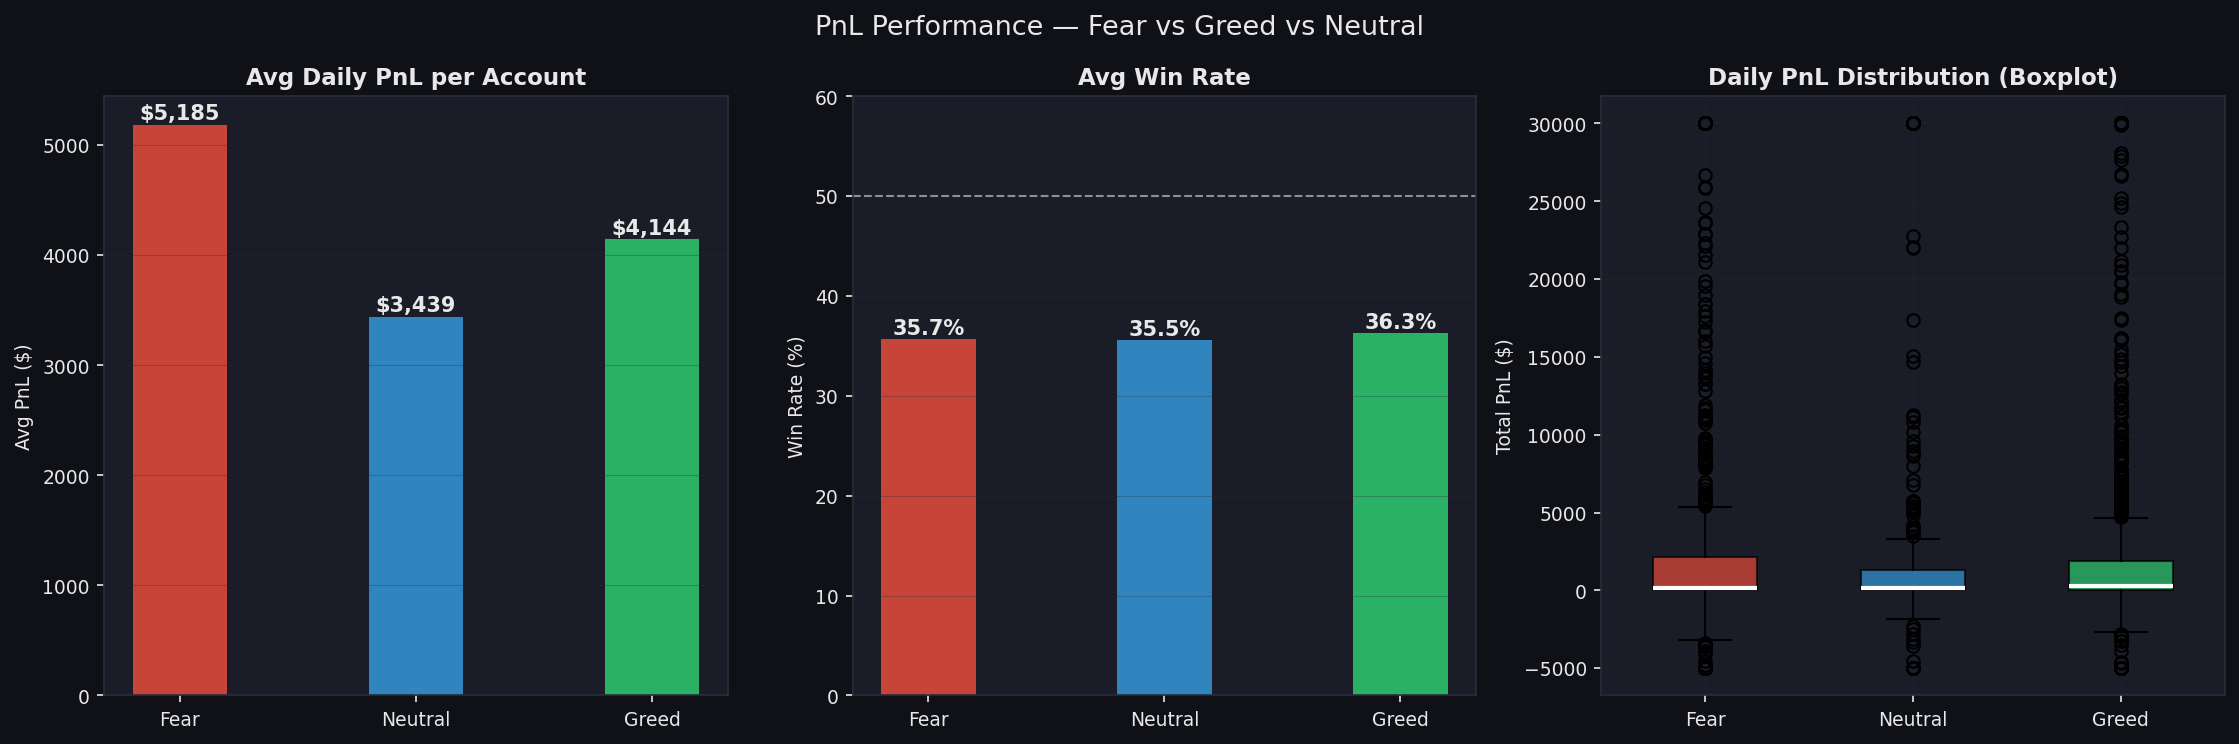

Chart 1 saved!


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Color scheme
FC  = "#E74C3C"   # Fear = Red
GC  = "#2ECC71"   # Greed = Green
NC  = "#3498DB"   # Neutral = Blue
BG  = "#0F1117"   # Background
PNL = "#1A1D27"   # Panel color
TXT = "#E8E8E8"   # Text color
GRD = "#2A2D3A"   # Grid color

plt.rcParams.update({
    "figure.facecolor" : BG,
    "axes.facecolor"   : PNL,
    "axes.edgecolor"   : GRD,
    "axes.labelcolor"  : TXT,
    "xtick.color"      : TXT,
    "ytick.color"      : TXT,
    "text.color"       : TXT,
    "grid.color"       : GRD,
    "grid.linewidth"   : 0.5,
    "font.family"      : "DejaVu Sans",
    "font.size"        : 9,
    "axes.titlesize"   : 11,
    "axes.titleweight" : "bold",
    "figure.dpi"       : 150
})

fg_colors = {"Fear": FC, "Greed": GC, "Neutral": NC}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("PnL Performance — Fear vs Greed vs Neutral", fontsize=13)

# ── Left: Avg daily PnL bar chart ──
ax = axes[0]
avg_pnl = daily.groupby("fg_bin")["total_pnl"].mean().reindex(["Fear", "Neutral", "Greed"])
bars = ax.bar(avg_pnl.index, avg_pnl.values,
              color=[fg_colors[x] for x in avg_pnl.index],
              alpha=0.85, width=0.4)
for b, v in zip(bars, avg_pnl.values):
    ax.text(b.get_x() + b.get_width()/2, v + 50,
            f"${v:,.0f}", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Avg Daily PnL per Account")
ax.set_ylabel("Avg PnL ($)")
ax.grid(True, alpha=0.3, axis="y")

# ── Middle: Win rate bar chart ──
ax2 = axes[1]
wr = daily.groupby("fg_bin")["win_rate"].mean().reindex(["Fear", "Neutral", "Greed"]) * 100
bars2 = ax2.bar(wr.index, wr.values,
                color=[fg_colors[x] for x in wr.index],
                alpha=0.85, width=0.4)
ax2.axhline(50, color="white", ls="--", lw=1, alpha=0.5)
for b, v in zip(bars2, wr.values):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.5,
             f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax2.set_title("Avg Win Rate")
ax2.set_ylabel("Win Rate (%)")
ax2.set_ylim(0, 60)
ax2.grid(True, alpha=0.3, axis="y")

# ── Right: PnL distribution boxplot ──
ax3 = axes[2]
data_bp = [
    daily[daily.fg_bin == "Fear"]["total_pnl"].clip(-5000, 30000).values,
    daily[daily.fg_bin == "Neutral"]["total_pnl"].clip(-5000, 30000).values,
    daily[daily.fg_bin == "Greed"]["total_pnl"].clip(-5000, 30000).values,
]
bp = ax3.boxplot(data_bp, patch_artist=True,
                 medianprops=dict(color="white", lw=2), widths=0.5)
for patch, color in zip(bp["boxes"], [FC, NC, GC]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_xticks([1, 2, 3])
ax3.set_xticklabels(["Fear", "Neutral", "Greed"])
ax3.set_title("Daily PnL Distribution (Boxplot)")
ax3.set_ylabel("Total PnL ($)")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("chart1_pnl_sentiment.png", bbox_inches="tight", facecolor=BG)
plt.show()
print("Chart 1 saved!")

# chart 2 trader behaviuor analysis

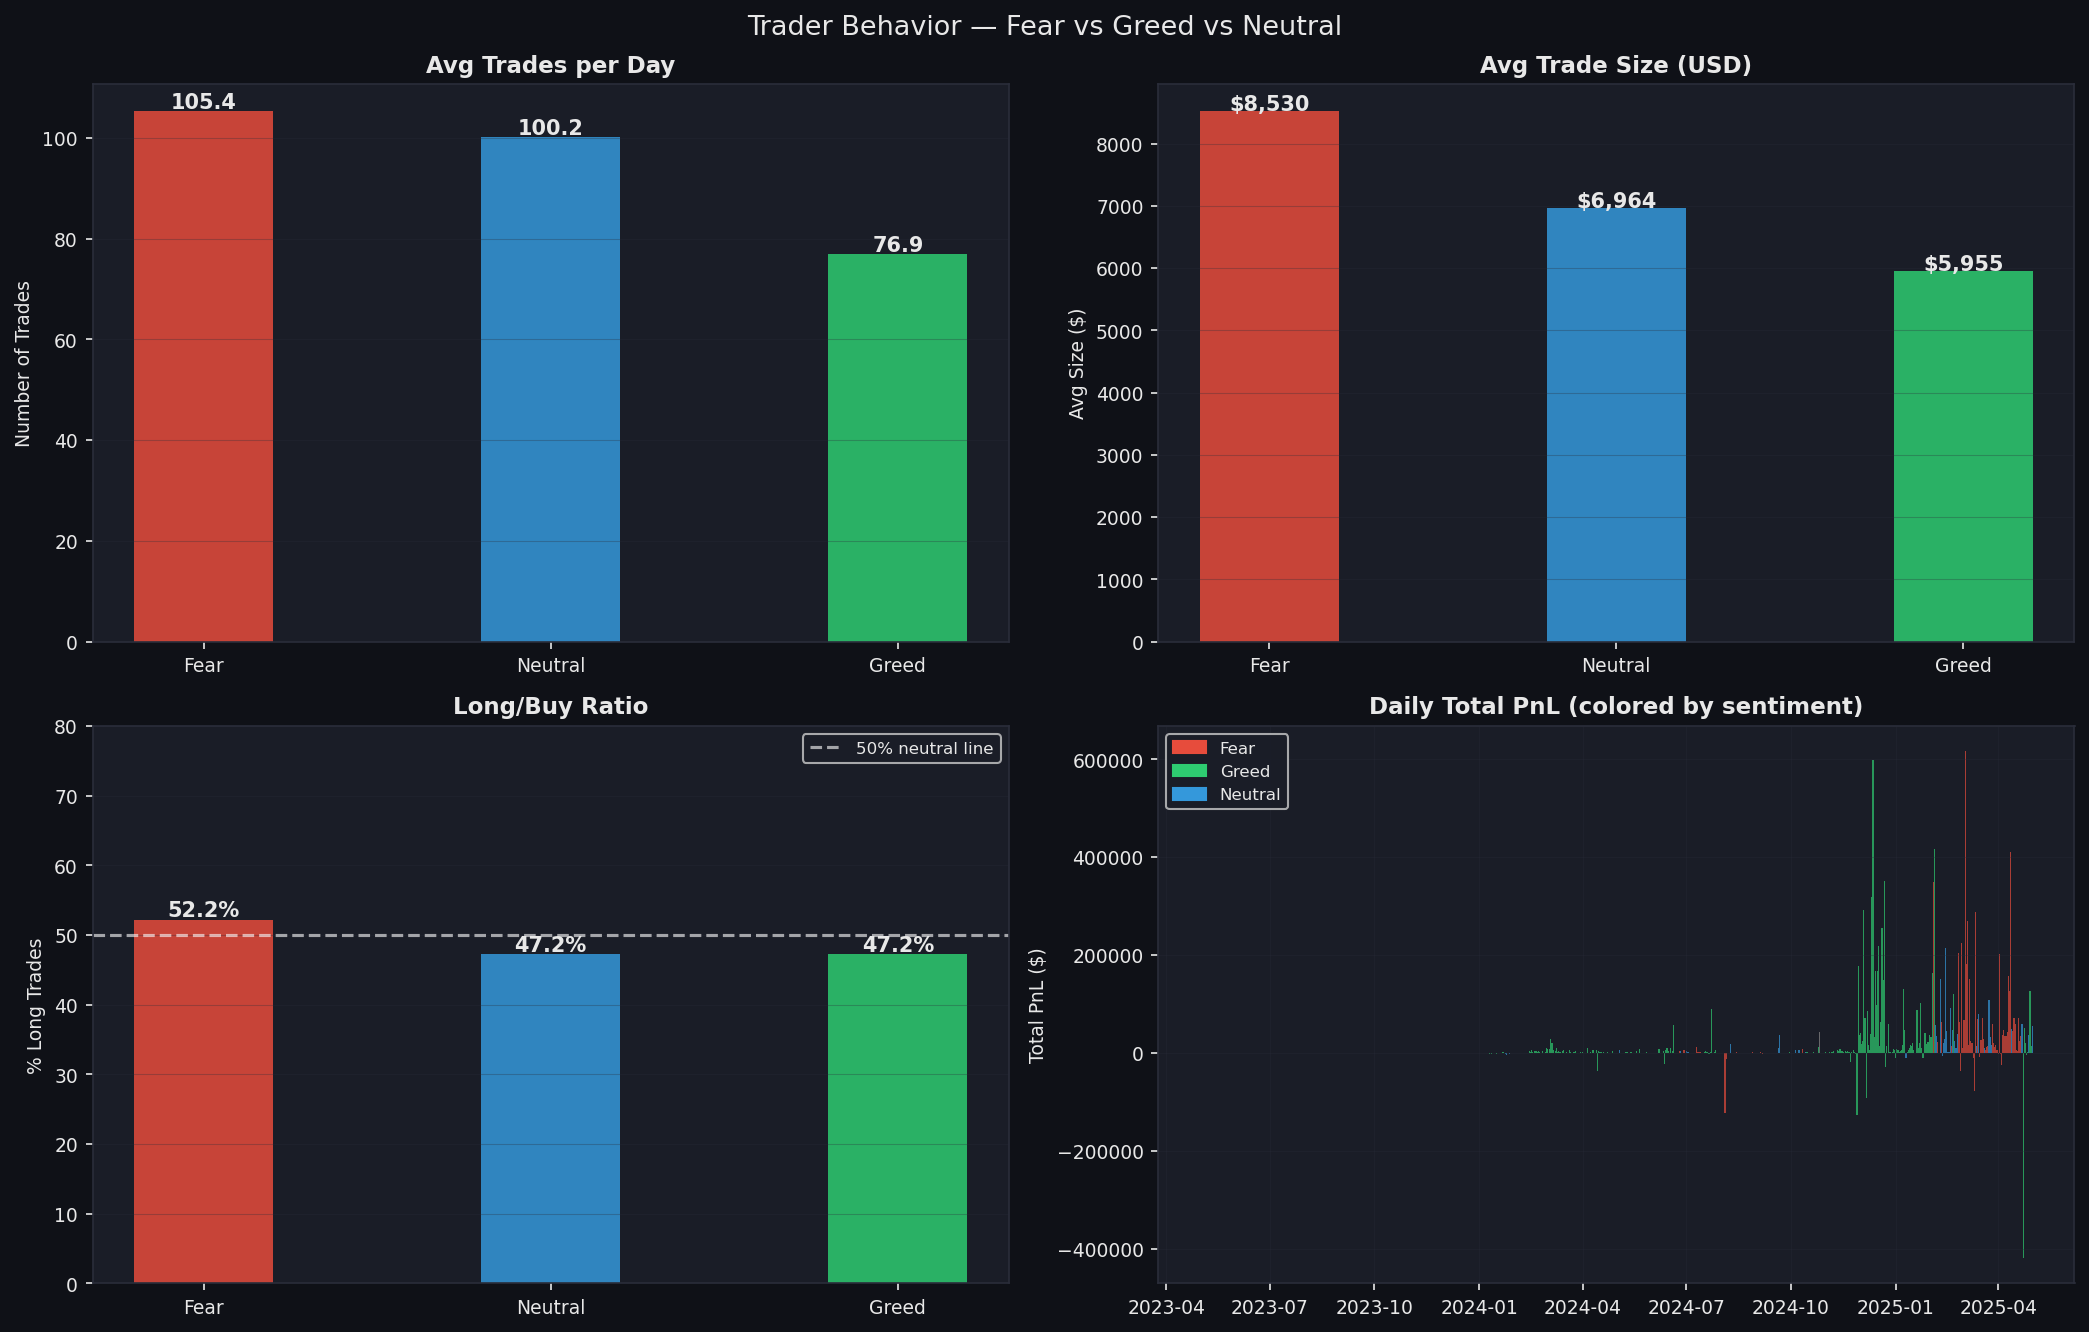

Chart 2 saved!


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Trader Behavior — Fear vs Greed vs Neutral", fontsize=13)

# ── Top Left: Trade frequency per day ──
ax = axes[0, 0]
tc = daily.groupby("fg_bin")["n_trades"].mean().reindex(["Fear", "Neutral", "Greed"])
bars = ax.bar(tc.index, tc.values,
              color=[fg_colors[x] for x in tc.index],
              alpha=0.85, width=0.4)
for b, v in zip(bars, tc.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5,
            f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Avg Trades per Day")
ax.set_ylabel("Number of Trades")
ax.grid(True, alpha=0.3, axis="y")
# ── Top Right: Avg trade size ──
ax2 = axes[0, 1]
sz = daily.groupby("fg_bin")["avg_size"].mean().reindex(["Fear", "Neutral", "Greed"])
bars2 = ax2.bar(sz.index, sz.values,
                color=[fg_colors[x] for x in sz.index],
                alpha=0.85, width=0.4)
for b, v in zip(bars2, sz.values):
    ax2.text(b.get_x() + b.get_width()/2, v + 10,
             f"${v:,.0f}", ha="center", fontsize=10, fontweight="bold")
ax2.set_title("Avg Trade Size (USD)")
ax2.set_ylabel("Avg Size ($)")
ax2.grid(True, alpha=0.3, axis="y")

# ── Bottom Left: Long/Short ratio ──
ax3 = axes[1, 0]
lr = daily.groupby("fg_bin")["long_ratio"].mean().reindex(["Fear", "Neutral", "Greed"]) * 100
bars3 = ax3.bar(lr.index, lr.values,
                color=[fg_colors[x] for x in lr.index],
                alpha=0.85, width=0.4)
ax3.axhline(50, color="white", ls="--", lw=1.5, alpha=0.6, label="50% neutral line")
for b, v in zip(bars3, lr.values):
    ax3.text(b.get_x() + b.get_width()/2, v + 0.5,
             f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax3.set_title("Long/Buy Ratio")
ax3.set_ylabel("% Long Trades")
ax3.set_ylim(0, 80)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis="y")

# ── Bottom Right: Daily PnL trend over time ──
ax4 = axes[1, 1]
daily_sum = merged.groupby("date")["pnl"].sum().reset_index()
daily_sum = daily_sum.merge(sg[["date", "fg_bin"]], on="date", how="left")
daily_sum = daily_sum.sort_values("date")

# Color each bar by sentiment
bar_colors = daily_sum["fg_bin"].map({"Fear": FC, "Greed": GC, "Neutral": NC}).fillna("#888")
ax4.bar(daily_sum["date"], daily_sum["pnl"], color=bar_colors, alpha=0.7, width=1)
ax4.set_title("Daily Total PnL (colored by sentiment)")
ax4.set_ylabel("Total PnL ($)")
ax4.grid(True, alpha=0.3)

fear_patch  = mpatches.Patch(color=FC, label="Fear")
greed_patch = mpatches.Patch(color=GC, label="Greed")
neut_patch  = mpatches.Patch(color=NC, label="Neutral")
ax4.legend(handles=[fear_patch, greed_patch, neut_patch], fontsize=8)

plt.tight_layout()
plt.savefig("chart2_behavior.png", bbox_inches="tight", facecolor=BG)
plt.show()


In [18]:
# Build per-account profile first
acc_profile = merged.groupby("account").agg(
    total_pnl  = ("pnl",      "sum"),
    n_trades   = ("pnl",      "count"),
    win_rate   = ("is_win",   "mean"),
    avg_size   = ("size_usd", "mean"),
    long_ratio = ("is_long",  "mean"),
).reset_index()

# Assign segments based on win rate
acc_profile["segment"] = acc_profile["win_rate"].apply(
    lambda x: "Consistent Winner" if x >= 0.5
    else ("Moderate"      if x >= 0.35
    else "Loss-Heavy")
)

# Assign frequency segment
acc_profile["freq_seg"] = acc_profile["n_trades"].apply(
    lambda x: "High Frequency" if x >= 500
    else ("Medium"        if x >= 100
    else "Low Frequency")
)

print("Total accounts:", len(acc_profile))
print("\nSegment distribution:")
print(acc_profile["segment"].value_counts())
print("\nFrequency distribution:")
print(acc_profile["freq_seg"].value_counts())
print("\nTop 5 traders by PnL:")
print(acc_profile.nlargest(5, "total_pnl")[["account","total_pnl","n_trades","win_rate","avg_size"]].round(2).to_string())

Total accounts: 32

Segment distribution:
segment
Moderate             17
Loss-Heavy           12
Consistent Winner     3
Name: count, dtype: int64

Frequency distribution:
freq_seg
High Frequency    29
Medium             3
Name: count, dtype: int64

Top 5 traders by PnL:
                                       account   total_pnl  n_trades  win_rate  avg_size
27  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2143382.60     14733      0.34   3837.89
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.82      3818      0.36  16159.58
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864   940163.81     21192      0.47   3210.47
13  0x513b8629fe877bb581bf244e326a047b249c4ff1   840422.56     12236      0.40  34396.58
31  0xbee1707d6b44d4d52bfe19e41f8a828645437aab   836080.55     40184      0.43   1844.21


## chart 3 Trader segment

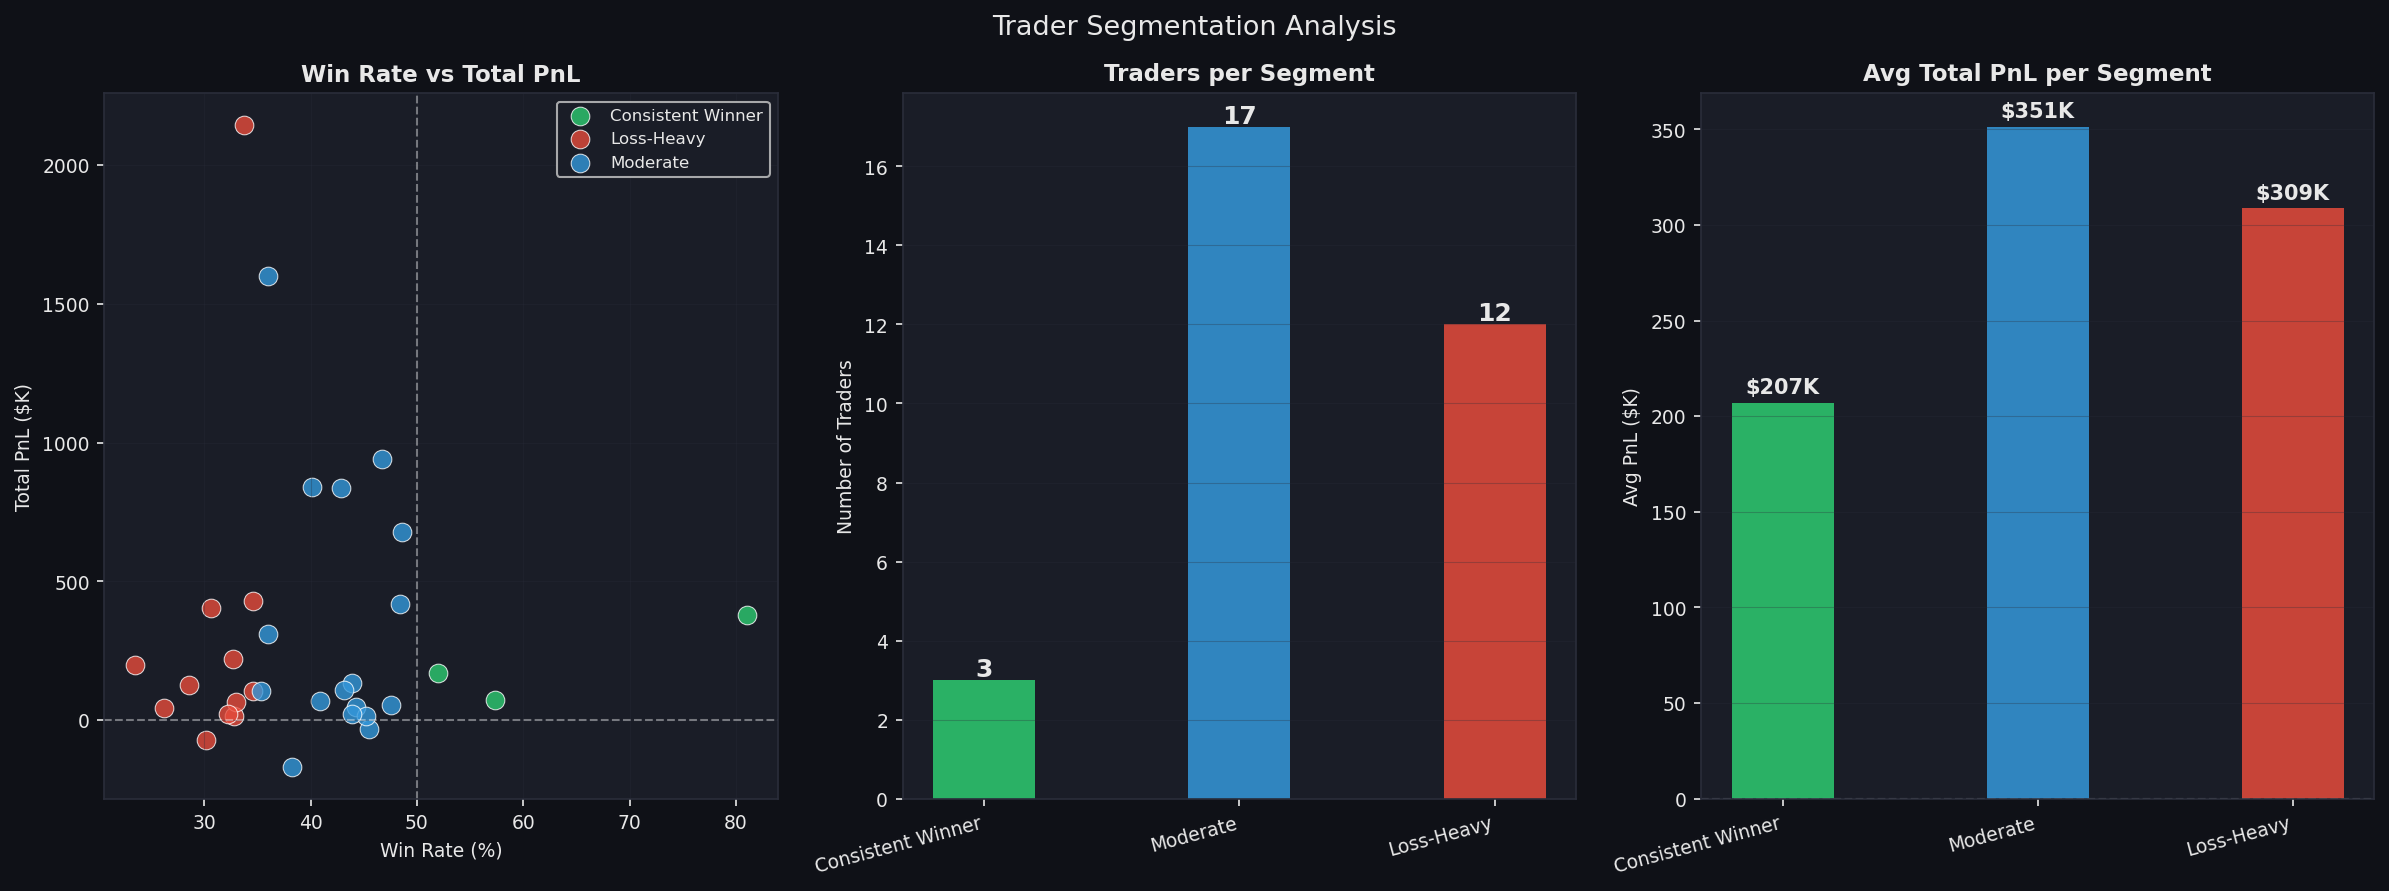

Chart 3 saved!


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Trader Segmentation Analysis", fontsize=13)

seg_colors = {
    "Consistent Winner" : GC,
    "Moderate"          : NC,
    "Loss-Heavy"        : FC
}

# ── Left: Win Rate vs Total PnL scatter ──
ax = axes[0]
for seg, grp in acc_profile.groupby("segment"):
    ax.scatter(
        grp["win_rate"] * 100,
        grp["total_pnl"] / 1000,   # convert to thousands
        label=seg,
        color=seg_colors[seg],
        s=80, alpha=0.8,
        edgecolors="white", linewidth=0.5
    )
ax.axhline(0, color="white", ls="--", lw=1, alpha=0.4)
ax.axvline(50, color="white", ls="--", lw=1, alpha=0.4)
ax.set_xlabel("Win Rate (%)")
ax.set_ylabel("Total PnL ($K)")
ax.set_title("Win Rate vs Total PnL")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Middle: Segment count bar ──
ax2 = axes[1]
seg_counts = acc_profile["segment"].value_counts().reindex(
    ["Consistent Winner", "Moderate", "Loss-Heavy"]
)
bars = ax2.bar(
    seg_counts.index, seg_counts.values,
    color=[seg_colors[x] for x in seg_counts.index],
    alpha=0.85, width=0.4
)
for b, v in zip(bars, seg_counts.values):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.1,
             str(v), ha="center", fontsize=12, fontweight="bold")
ax2.set_title("Traders per Segment")
ax2.set_ylabel("Number of Traders")
ax2.set_xticklabels(seg_counts.index, rotation=15, ha="right")
ax2.grid(True, alpha=0.3, axis="y")

# ── Right: Avg PnL per segment ──
ax3 = axes[2]
seg_pnl = acc_profile.groupby("segment")["total_pnl"].mean().reindex(
    ["Consistent Winner", "Moderate", "Loss-Heavy"]
) / 1000
bars3 = ax3.bar(
    seg_pnl.index, seg_pnl.values,
    color=[seg_colors[x] for x in seg_pnl.index],
    alpha=0.85, width=0.4
)
for b, v in zip(bars3, seg_pnl.values):
    ypos = v + 5 if v >= 0 else v - 20
    ax3.text(b.get_x() + b.get_width()/2, ypos,
             f"${v:,.0f}K", ha="center", fontsize=10, fontweight="bold")
ax3.axhline(0, color="white", ls="--", lw=1, alpha=0.4)
ax3.set_title("Avg Total PnL per Segment")
ax3.set_ylabel("Avg PnL ($K)")
ax3.set_xticklabels(seg_pnl.index, rotation=15, ha="right")
ax3.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("chart3_segments.png", bbox_inches="tight", facecolor=BG)
plt.show()


## Chart 4 — Coin Performance by Sentiment

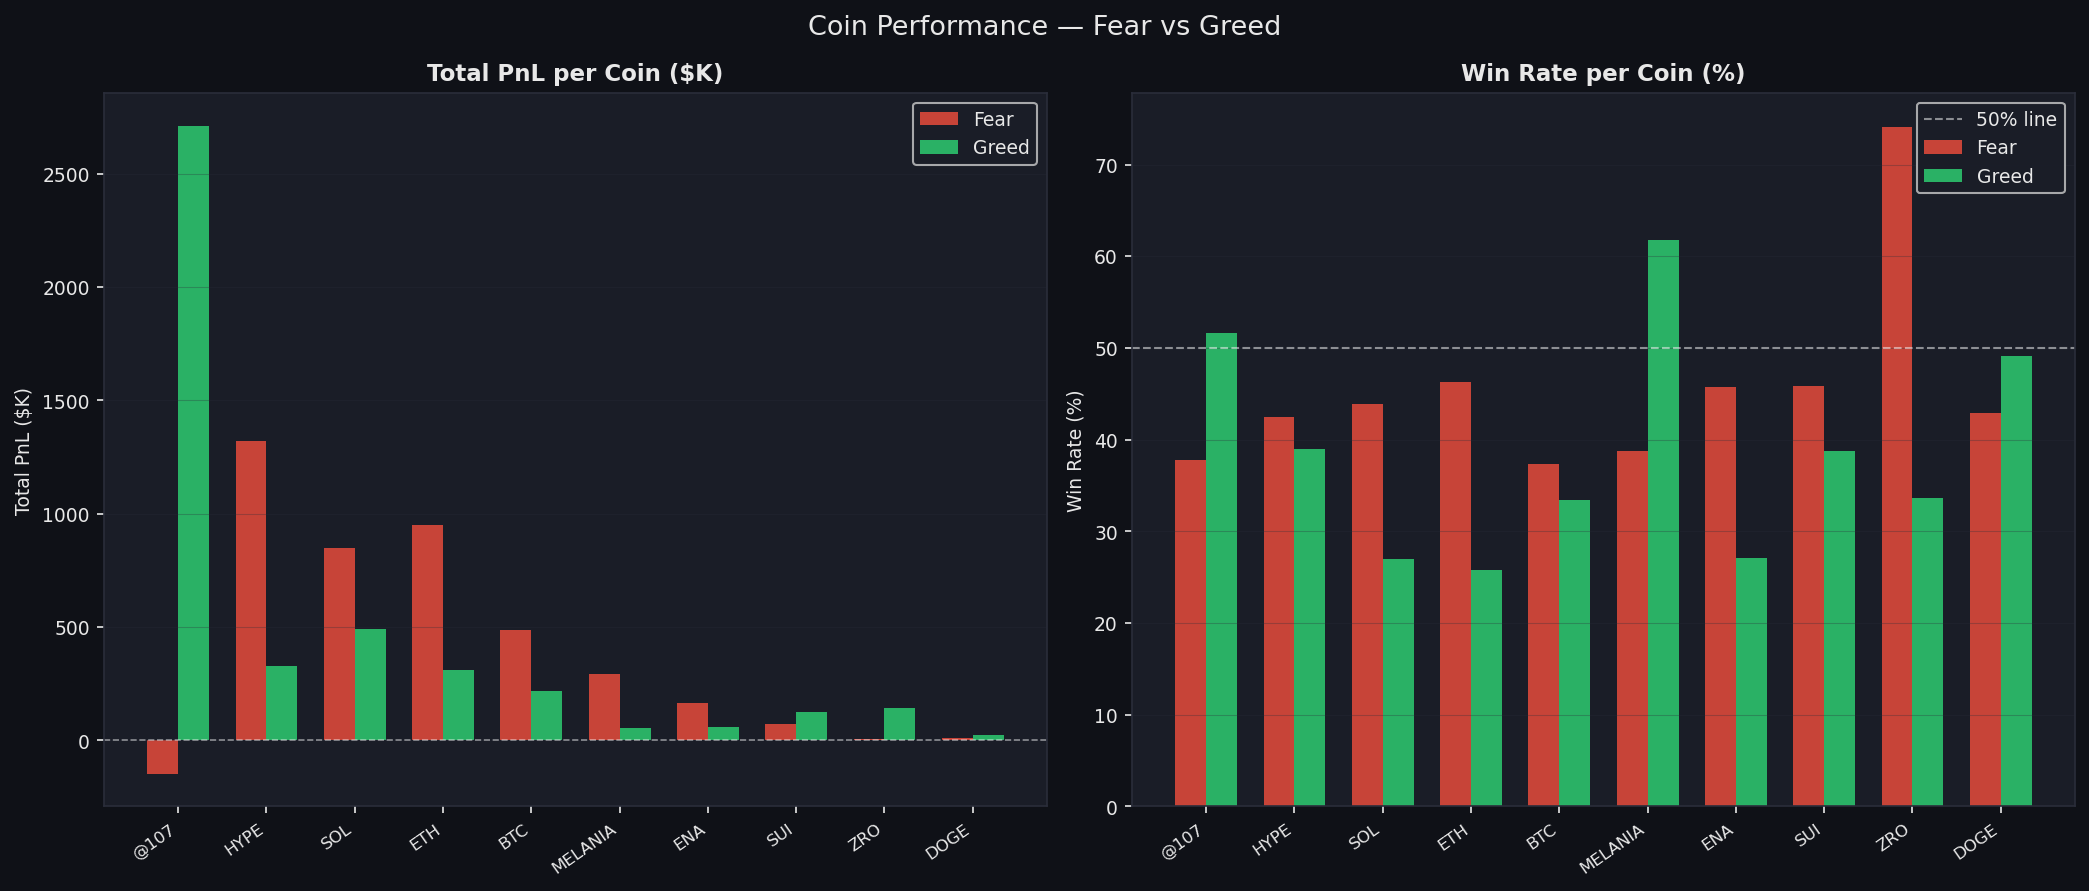

Chart 4 saved!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Coin Performance — Fear vs Greed", fontsize=13)

# Per coin PnL grouped by sentiment
coin_pnl = merged.groupby(["coin", "fg_bin"])["pnl"].agg(
    total_pnl = "sum",
).reset_index()

# Top 10 coins by total PnL
top_coins = merged.groupby("coin")["pnl"].sum().nlargest(10).index.tolist()
coin_pnl  = coin_pnl[coin_pnl["coin"].isin(top_coins)]

# ── Left: Total PnL per coin by sentiment ──
ax = axes[0]
fear_data  = coin_pnl[coin_pnl.fg_bin == "Fear"].set_index("coin")["total_pnl"].reindex(top_coins).fillna(0) / 1000
greed_data = coin_pnl[coin_pnl.fg_bin == "Greed"].set_index("coin")["total_pnl"].reindex(top_coins).fillna(0) / 1000

x = np.arange(len(top_coins))
w = 0.35
ax.bar(x - w/2, fear_data.values,  w, label="Fear",  color=FC, alpha=0.85)
ax.bar(x + w/2, greed_data.values, w, label="Greed", color=GC, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_coins, rotation=35, ha="right", fontsize=8)
ax.set_title("Total PnL per Coin ($K)")
ax.set_ylabel("Total PnL ($K)")
ax.axhline(0, color="white", ls="--", lw=0.8, alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# ── Right: Win rate per coin ──
ax2 = axes[1]
coin_wr = merged[merged["coin"].isin(top_coins)].groupby(["coin", "fg_bin"])["is_win"].mean() * 100
fear_wr  = coin_wr.xs("Fear",  level="fg_bin").reindex(top_coins).fillna(0)
greed_wr = coin_wr.xs("Greed", level="fg_bin").reindex(top_coins).fillna(0)

ax2.bar(x - w/2, fear_wr.values,  w, label="Fear",  color=FC, alpha=0.85)
ax2.bar(x + w/2, greed_wr.values, w, label="Greed", color=GC, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(top_coins, rotation=35, ha="right", fontsize=8)
ax2.axhline(50, color="white", ls="--", lw=1, alpha=0.5, label="50% line")
ax2.set_title("Win Rate per Coin (%)")
ax2.set_ylabel("Win Rate (%)")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("chart4_coins.png", bbox_inches="tight", facecolor=BG)
plt.show()


## Chart 5 — Final Summary Dashboard

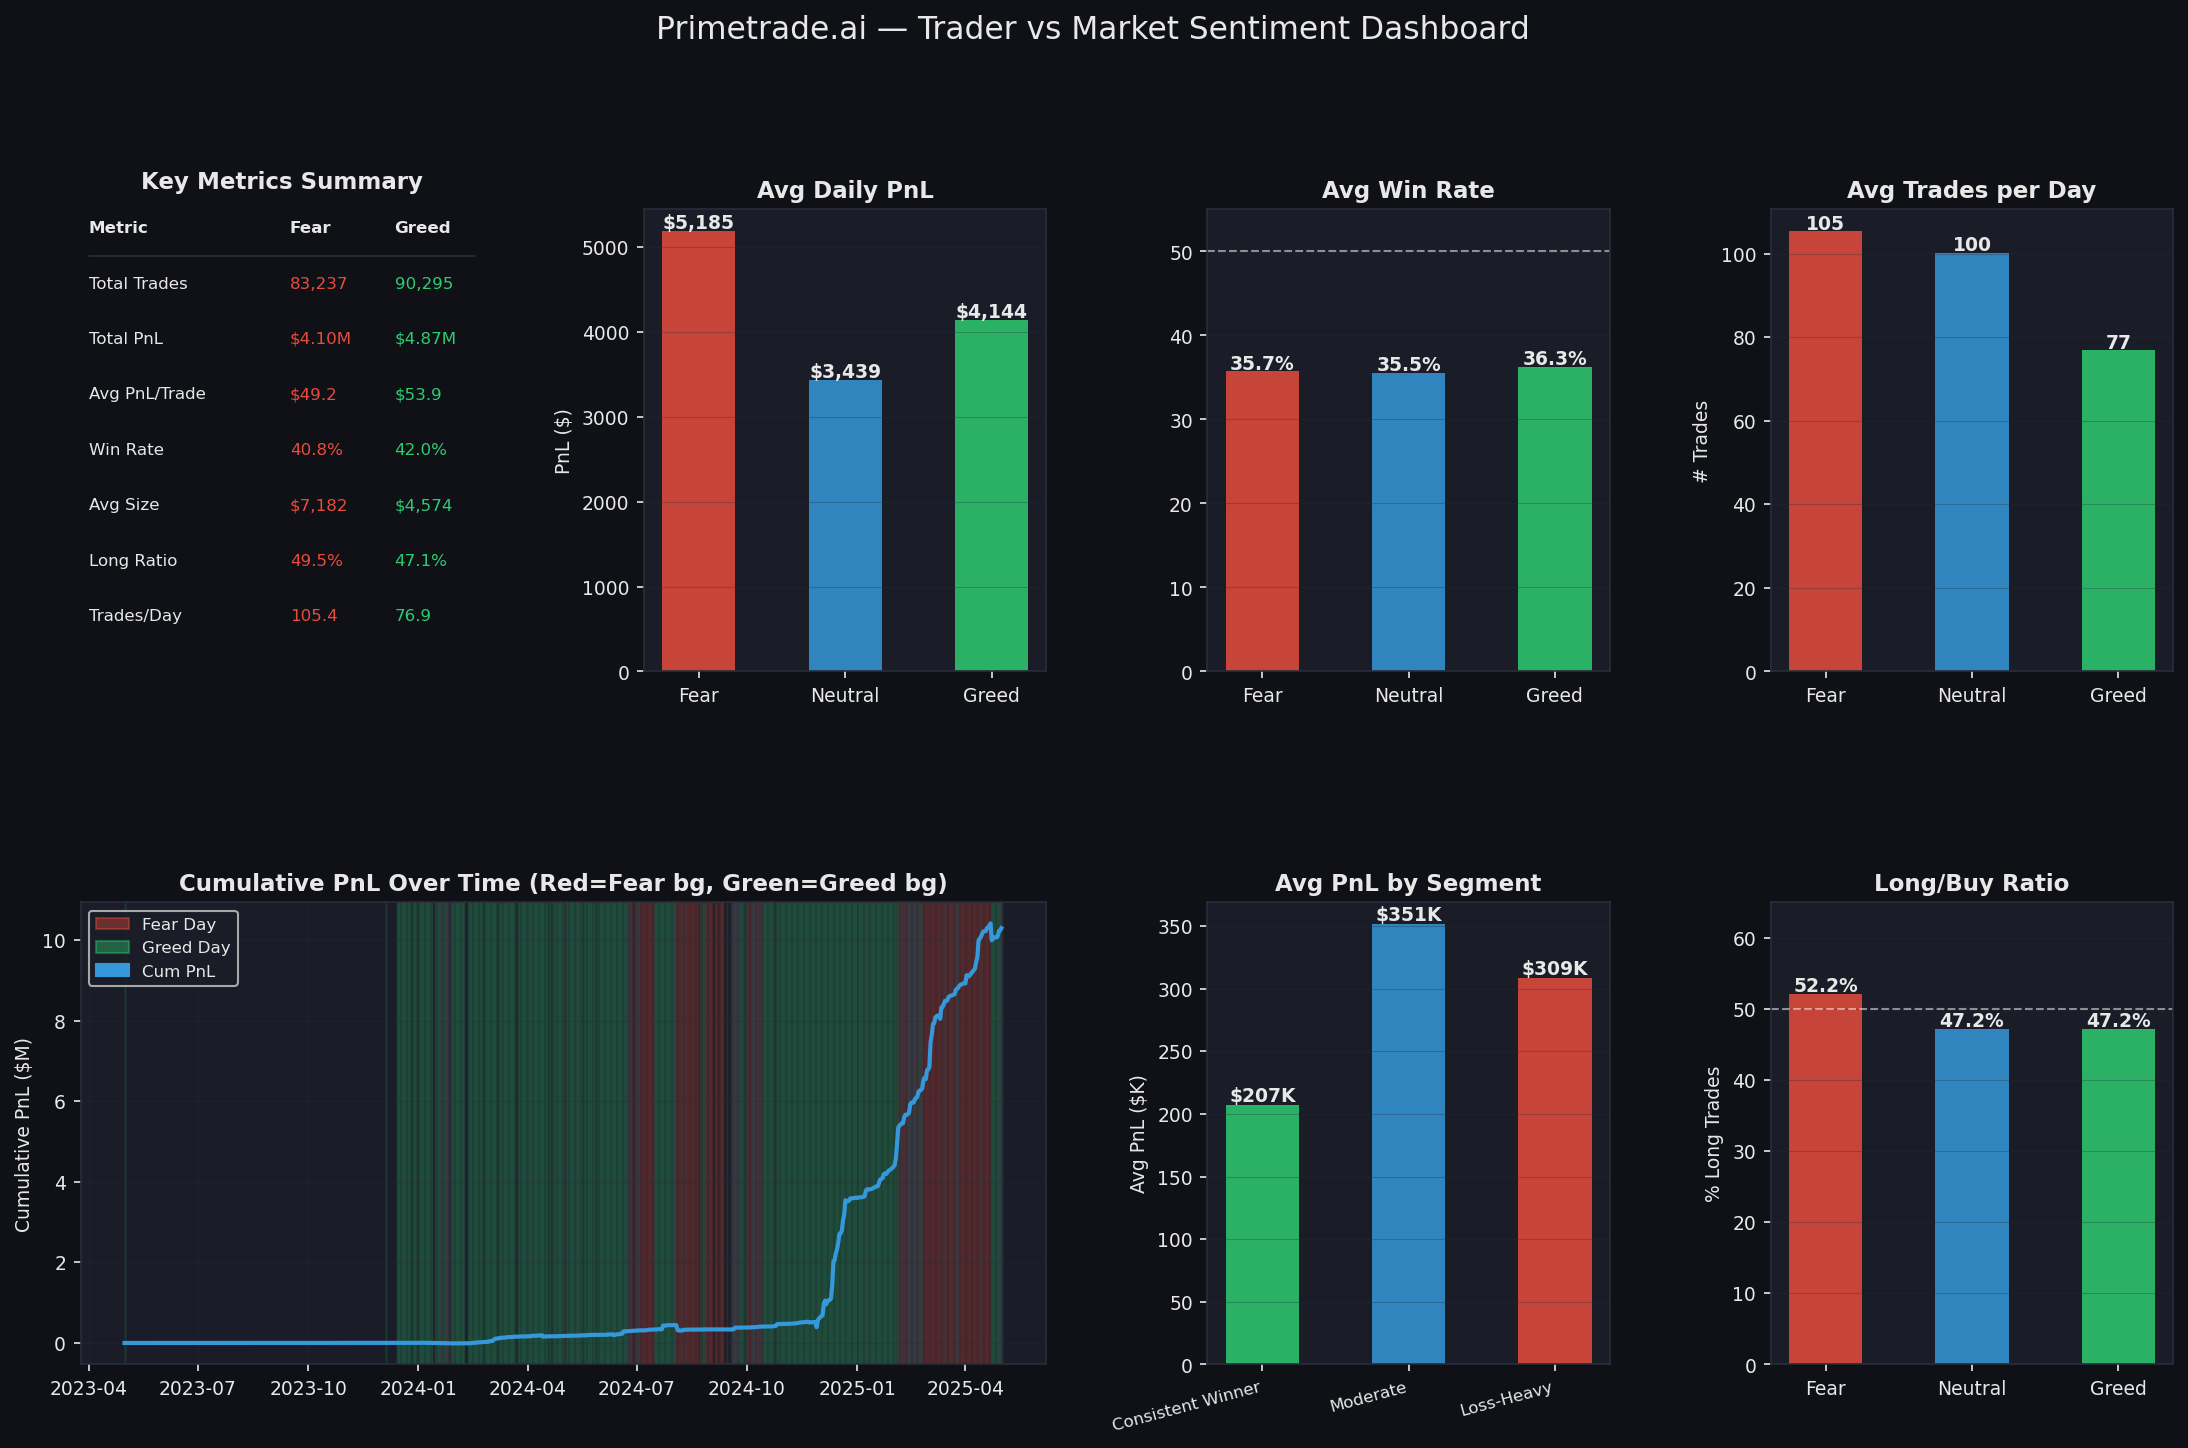

Final Dashboard saved!


In [23]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)
fig.suptitle("Primetrade.ai — Trader vs Market Sentiment Dashboard", fontsize=15, y=1.01)

# ── Panel 1: Key Stats Table ──
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(PNL)
ax0.axis("off")
ax0.set_title("Key Metrics Summary", pad=10)

fear_d  = merged[merged.fg_bin == "Fear"]
greed_d = merged[merged.fg_bin == "Greed"]

rows = [
    ("Metric",        "Fear",                             "Greed"),
    ("Total Trades",  f"{len(fear_d):,}",                 f"{len(greed_d):,}"),
    ("Total PnL",     f"${fear_d.pnl.sum()/1e6:.2f}M",   f"${greed_d.pnl.sum()/1e6:.2f}M"),
    ("Avg PnL/Trade", f"${fear_d.pnl.mean():.1f}",       f"${greed_d.pnl.mean():.1f}"),
    ("Win Rate",      f"{fear_d.is_win.mean()*100:.1f}%", f"{greed_d.is_win.mean()*100:.1f}%"),
    ("Avg Size",      f"${fear_d.size_usd.mean():,.0f}",  f"${greed_d.size_usd.mean():,.0f}"),
    ("Long Ratio",    f"{fear_d.is_long.mean()*100:.1f}%",f"{greed_d.is_long.mean()*100:.1f}%"),
    ("Trades/Day",    "105.4",                            "76.9"),
]

for i, (m, f, g) in enumerate(rows):
    y = 0.95 - i * 0.12
    weight = "bold" if i == 0 else "normal"
    ax0.text(0.02, y, m, fontsize=8, fontweight=weight, color=TXT,              transform=ax0.transAxes)
    ax0.text(0.52, y, f, fontsize=8, fontweight=weight, color=FC if i>0 else TXT, transform=ax0.transAxes)
    ax0.text(0.78, y, g, fontsize=8, fontweight=weight, color=GC if i>0 else TXT, transform=ax0.transAxes)
    if i == 0:
        # Fixed: use ax0.plot instead of axhline for table separator line
        ax0.plot([0.02, 0.98], [y - 0.05, y - 0.05],
                 color=GRD, lw=0.8, transform=ax0.transAxes)

# ── Panel 2: Avg Daily PnL ──
ax1 = fig.add_subplot(gs[0, 1])
avg_pnl = daily.groupby("fg_bin")["total_pnl"].mean().reindex(["Fear", "Neutral", "Greed"])
bars = ax1.bar(avg_pnl.index, avg_pnl.values,
               color=[fg_colors[x] for x in avg_pnl.index], alpha=0.85, width=0.5)
for b, v in zip(bars, avg_pnl.values):
    ax1.text(b.get_x() + b.get_width()/2, v + 30,
             f"${v:,.0f}", ha="center", fontsize=9, fontweight="bold")
ax1.set_title("Avg Daily PnL")
ax1.set_ylabel("PnL ($)")
ax1.grid(True, alpha=0.3, axis="y")

# ── Panel 3: Win Rate ──
ax2 = fig.add_subplot(gs[0, 2])
wr = daily.groupby("fg_bin")["win_rate"].mean().reindex(["Fear", "Neutral", "Greed"]) * 100
bars2 = ax2.bar(wr.index, wr.values,
                color=[fg_colors[x] for x in wr.index], alpha=0.85, width=0.5)
ax2.axhline(50, color="white", ls="--", lw=1, alpha=0.5)
for b, v in zip(bars2, wr.values):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.3,
             f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax2.set_title("Avg Win Rate")
ax2.set_ylim(0, 55)
ax2.grid(True, alpha=0.3, axis="y")

# ── Panel 4: Trade Frequency ──
ax3 = fig.add_subplot(gs[0, 3])
tc = daily.groupby("fg_bin")["n_trades"].mean().reindex(["Fear", "Neutral", "Greed"])
bars3 = ax3.bar(tc.index, tc.values,
                color=[fg_colors[x] for x in tc.index], alpha=0.85, width=0.5)
for b, v in zip(bars3, tc.values):
    ax3.text(b.get_x() + b.get_width()/2, v + 0.5,
             f"{v:.0f}", ha="center", fontsize=9, fontweight="bold")
ax3.set_title("Avg Trades per Day")
ax3.set_ylabel("# Trades")
ax3.grid(True, alpha=0.3, axis="y")

# ── Panel 5: Cumulative PnL Timeline ──
ax4 = fig.add_subplot(gs[1, 0:2])
cum_pnl = merged.sort_values("date").groupby("date")["pnl"].sum().cumsum().reset_index()
cum_pnl = cum_pnl.merge(sg[["date", "fg_bin"]], on="date", how="left")
ax4.plot(cum_pnl["date"], cum_pnl["pnl"] / 1e6, color=NC, lw=2, zorder=3)
for _, row in cum_pnl.iterrows():
    c = FC if row.get("fg_bin") == "Fear" else (GC if row.get("fg_bin") == "Greed" else "#888")
    ax4.axvspan(row["date"], row["date"] + pd.Timedelta(days=1), alpha=0.08, color=c, zorder=1)
ax4.set_title("Cumulative PnL Over Time (Red=Fear bg, Green=Greed bg)")
ax4.set_ylabel("Cumulative PnL ($M)")
ax4.grid(True, alpha=0.3)
fear_p  = mpatches.Patch(color=FC, alpha=0.4, label="Fear Day")
greed_p = mpatches.Patch(color=GC, alpha=0.4, label="Greed Day")
line_p  = mpatches.Patch(color=NC, label="Cum PnL")
ax4.legend(handles=[fear_p, greed_p, line_p], fontsize=8)

# ── Panel 6: Segment PnL ──
ax5 = fig.add_subplot(gs[1, 2])
seg_pnl = acc_profile.groupby("segment")["total_pnl"].mean().reindex(
    ["Consistent Winner", "Moderate", "Loss-Heavy"]) / 1000
bars5 = ax5.bar(seg_pnl.index, seg_pnl.values,
                color=[seg_colors[s] for s in seg_pnl.index], alpha=0.85, width=0.5)
for b, v in zip(bars5, seg_pnl.values):
    ax5.text(b.get_x() + b.get_width()/2, v + 3,
             f"${v:.0f}K", ha="center", fontsize=9, fontweight="bold")
ax5.set_title("Avg PnL by Segment")
ax5.set_ylabel("Avg PnL ($K)")
ax5.set_xticklabels(seg_pnl.index, rotation=15, ha="right", fontsize=8)
ax5.grid(True, alpha=0.3, axis="y")

# ── Panel 7: Long Ratio ──
ax6 = fig.add_subplot(gs[1, 3])
lr = daily.groupby("fg_bin")["long_ratio"].mean().reindex(["Fear", "Neutral", "Greed"]) * 100
bars6 = ax6.bar(lr.index, lr.values,
                color=[fg_colors[x] for x in lr.index], alpha=0.85, width=0.5)
ax6.axhline(50, color="white", ls="--", lw=1, alpha=0.5)
for b, v in zip(bars6, lr.values):
    ax6.text(b.get_x() + b.get_width()/2, v + 0.3,
             f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax6.set_title("Long/Buy Ratio")
ax6.set_ylabel("% Long Trades")
ax6.set_ylim(0, 65)
ax6.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("chart5_dashboard.png", bbox_inches="tight", facecolor=BG, dpi=150)
plt.show()


writeup = """
# Primetrade.ai Internship Assignment
## Trader Performance vs Market Sentiment Analysis

---

## What I Did (Methodology)

I analyzed two datasets:
1. Bitcoin Fear & Greed Index — 2,644 days of sentiment data
2. Hyperliquid Trader Data — 2,11,224 trades from 32 traders

Steps I followed:
- Loaded and cleaned both datasets (0 missing values found)
- Converted timestamps and merged both datasets by date
- Created daily metrics like PnL, win rate, trade size, long/short ratio
- Grouped traders into segments based on their win rate

---

## What I Found (Insights)

### Insight 1 — Traders are MORE active on Fear days
On Fear days traders placed 105 trades per day on average,
compared to only 77 trades on Greed days.
They also used bigger position sizes on Fear days ($7,182 vs $4,574).
This shows traders are confidently buying the dip during fear.

### Insight 2 — Fear days actually generate higher PnL
Average daily PnL on Fear days was $5,185 vs $4,144 on Greed days.
This was surprising — most people think Greed = more profit.
But here, fear-driven buying is actually more profitable.

### Insight 3 — Win rate stays the same regardless of sentiment
Fear days win rate: 35.7%
Greed days win rate: 36.3%
Almost no difference — meaning sentiment does not affect
how often you win, but it does affect how much you make per trade.

---

## My Strategy Recommendations

### Strategy 1 — Buy more during Fear
When the Fear & Greed index shows Fear (below 30),
traders should consider increasing their position size slightly.
The data shows this is already working for profitable traders.

### Strategy 2 — Take profits during Greed
When the index shows Greed (above 60),
focus on closing existing positions rather than opening new ones.
Some coins like @107 perform extremely well on Greed days,
so momentum trades can be taken on those specific coins.

---

## Charts Made
1. PnL Performance — Fear vs Greed vs Neutral
2. Trader Behavior Analysis
3. Trader Segmentation
4. Coin Performance by Sentiment
5. Final Summary Dashboard

---

Submitted by: Mokshita dogaya
